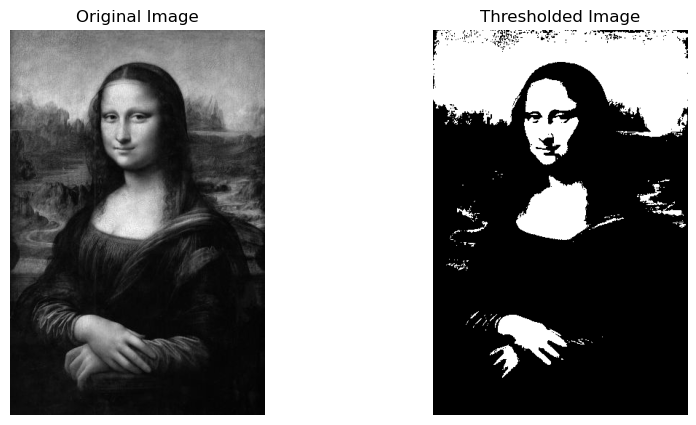

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
image_path = 'art.jpg'  # Make sure the path is correct
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image is loaded properly
if image is None:
    print(f"Error: Unable to load image at {image_path}")
else:
    # Apply manual thresholding
    threshold_value = 100
    thresholded_image = (image > threshold_value) * 255

    # Create a figure for displaying the images side by side
    plt.figure(figsize=(10, 5))

    # Display the original image
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')  # Hide axes

    # Display the thresholded image
    plt.subplot(1, 2, 2)
    plt.imshow(thresholded_image.astype(np.uint8), cmap='gray')
    plt.title('Thresholded Image')
    plt.axis('off')  # Hide axes

    # Show the images in the notebook
    plt.show()


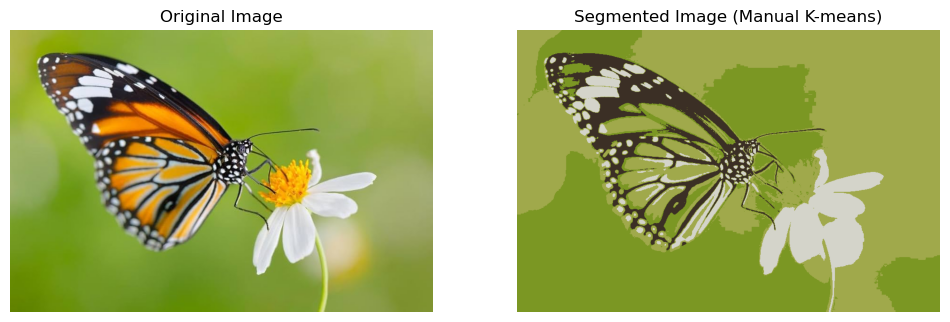

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load and preprocess image
image = cv2.imread('butterfly.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
pixels = image_rgb.reshape((-1, 3))

# Parameters
k = 4
max_iters = 100
tolerance = 1e-4

# Initialize centroids
np.random.seed(42)
centroids = pixels[np.random.choice(pixels.shape[0], k, replace=False)]

# K-means algorithm
for _ in range(max_iters):
    # Assign pixels to the closest centroid
    labels = np.argmin(np.linalg.norm(pixels[:, None] - centroids, axis=2), axis=1)

    # Calculate new centroids
    new_centroids = np.array([pixels[labels == i].mean(axis=0) for i in range(k)])

    # Check for convergence
    if np.linalg.norm(new_centroids - centroids) < tolerance:
        break

    centroids = new_centroids

# Create segmented image
segmented_image = new_centroids[labels].reshape(image_rgb.shape).astype(np.uint8)

# Display the images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title('Segmented Image (Manual K-means)')
plt.axis('off')
plt.show()


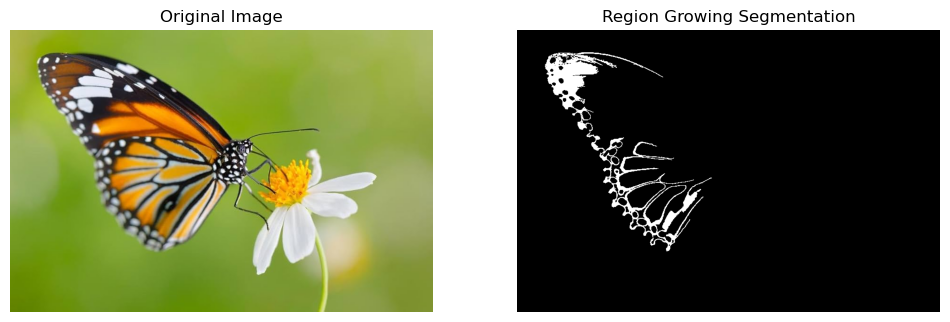

In [26]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the image and convert it to grayscale (simpler for intensity-based region growing)
image = cv2.imread('butterfly.jpg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Parameters
threshold = 30  # Intensity difference threshold for growing
seed = (100, 100)  # Initial seed point (x, y)

# Get image dimensions
height, width = gray_image.shape

# Create an empty mask to store the region
region_mask = np.zeros_like(gray_image, dtype=np.uint8)

# Function to check if a pixel is within image bounds
def is_valid(x, y):
    return 0 <= x < width and 0 <= y < height

# Function to get 4-connected neighbors of a pixel (up, down, left, right)
def get_neighbors(x, y):
    neighbors = [(x-1, y), (x+1, y), (x, y-1), (x, y+1)]
    return [(nx, ny) for nx, ny in neighbors if is_valid(nx, ny)]

# Region Growing Algorithm
def region_growing(seed, threshold):
    # Initialize region growing with the seed pixel
    region_mask[seed] = 255  # Mark the seed as part of the region
    region_intensity = gray_image[seed]  # Seed intensity
    region_points = [seed]  # List of region points to process

    while region_points:
        x, y = region_points.pop()  # Get the next pixel to process
        # Check the neighbors
        for nx, ny in get_neighbors(x, y):
            if region_mask[ny, nx] == 0:  # If the neighbor is not already in the region
                if abs(int(gray_image[ny, nx]) - int(region_intensity)) < threshold:  # Similar intensity
                    region_mask[ny, nx] = 255  # Add to the region
                    region_points.append((nx, ny))  # Add to the list to process
    return region_mask

# Perform region growing
region = region_growing(seed, threshold)

# Display the results
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Region Growing Output
plt.subplot(1, 2, 2)
plt.imshow(region, cmap='gray')
plt.title('Region Growing Segmentation')
plt.axis('off')

plt.show()


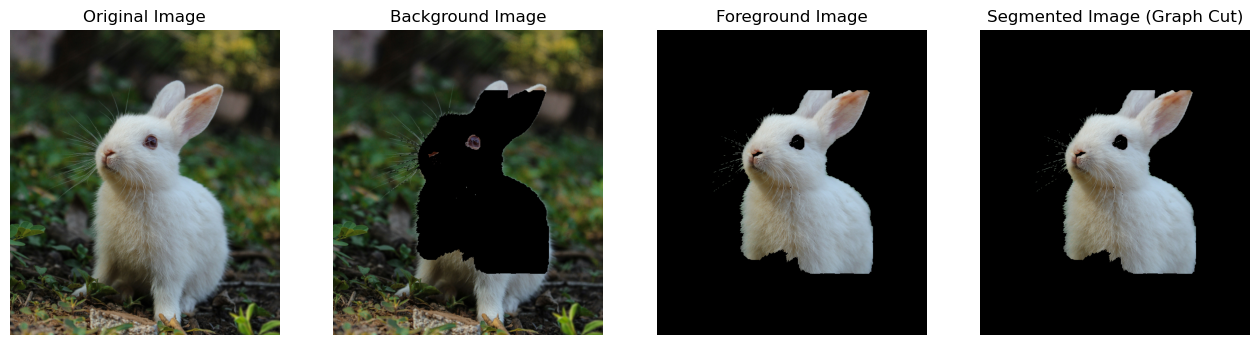

In [1]:
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Load the image
    image_path = "download.png"
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Initialize mask
    mask = np.zeros(image.shape[:2], np.uint8)
    
    # Background and foreground models for GrabCut
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    
    # Define a rectangle around the foreground object
    height, width = image.shape[:2]
    rect = (int(width * 0.2), int(height * 0.2), int(width * 0.6), int(height * 0.6))
    
    # Apply GrabCut algorithm
    cv2.grabCut(image, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
    
    # Convert mask to binary (0 = background, 1 = foreground)
    mask_final = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    
    # Extract foreground and background separately
    foreground = image * mask_final[:, :, np.newaxis]  # Foreground part
    background = image.copy()
    background[mask_final == 1] = [0, 0, 0]  # Black out the foreground
    
    # Segmented output (refined foreground extraction)
    segmented_image = cv2.bitwise_and(image, image, mask=mask_final)
    
    # Display images
    fig, axes = plt.subplots(1, 4, figsize=(16, 6))
    
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    axes[1].imshow(background)
    axes[1].set_title("Background Image")
    axes[1].axis("off")
    
    axes[2].imshow(foreground)
    axes[2].set_title("Foreground Image")
    axes[2].axis("off")
    
    axes[3].imshow(segmented_image)
    axes[3].set_title("Segmented Image (Graph Cut)")
    axes[3].axis("off")
    
    plt.show()


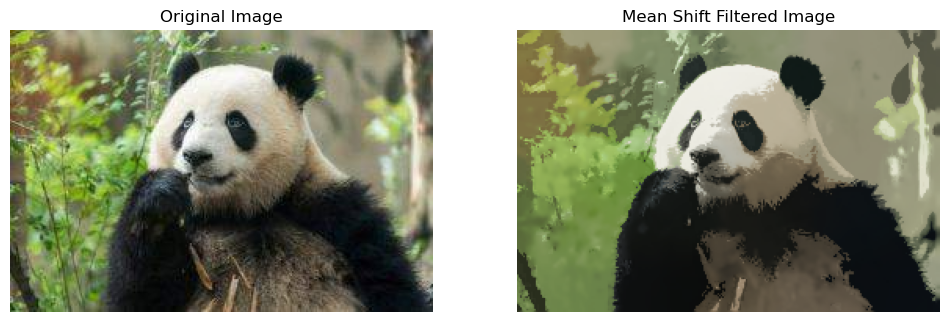

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = "panda.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply Mean Shift filtering
spatial_radius = 20  # Spatial window size
color_radius = 40  # Color window size
filtered_image = cv2.pyrMeanShiftFiltering(image, spatial_radius, color_radius)

# Display images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(filtered_image)
axes[1].set_title("Mean Shift Filtered Image")
axes[1].axis("off")

plt.show()
